#**Customer Churn Prediction – Exploratory Data Analysis**

# Importing Required Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


#Loading the Dataset

In [9]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print(df.shape)

(7043, 21)


# Cleaning and Preprocessing

In [11]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce")
print(df.isnull().sum())
df= df.dropna(subset=["TotalCharges"])
print("New Shape: ")
print(df.shape)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
New Shape: 
(7032, 21)


#Churn Distribution

Customers who churned and how many stayed.

Churn
No     5163
Yes    1869
Name: count, dtype: int64


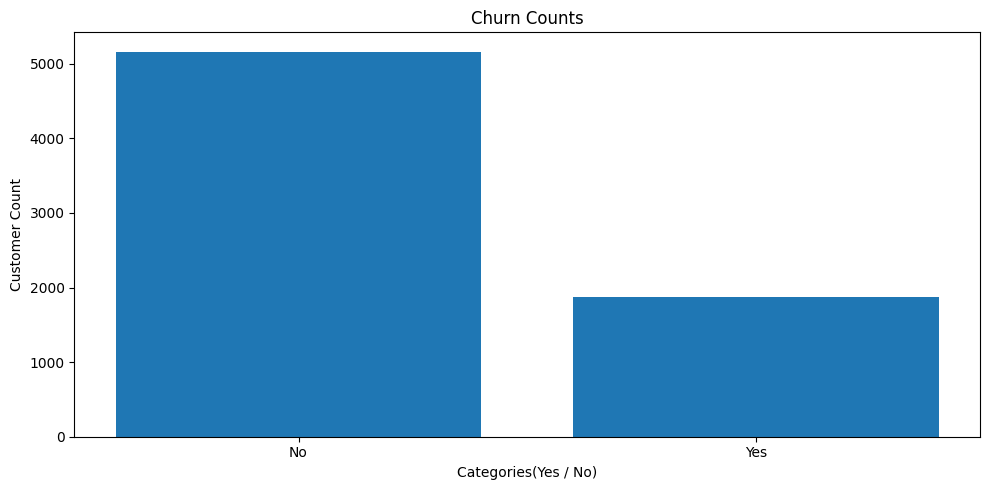

Churn percentage: 
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [44]:
fig, ax=plt.subplots(figsize=(10,5))
churn_counts=df["Churn"].value_counts()
print(churn_counts)
ax.bar(churn_counts.keys(), churn_counts.values)
ax.set(title="Churn Counts")
ax.set(xlabel="Categories(Yes / No)")
ax.set(ylabel="Customer Count")
plt.tight_layout()
plt.show()

print("Churn percentage: ")
print(df["Churn"].value_counts(normalize=True)*100)


### **Observation:**

Around 26% of customers churned, while 74% stayed.  
This means the dataset is slightly imbalanced and we may need to handle this during modeling.

# Tenure vs Churn
Customer tenure for those who churned and those who stayed.




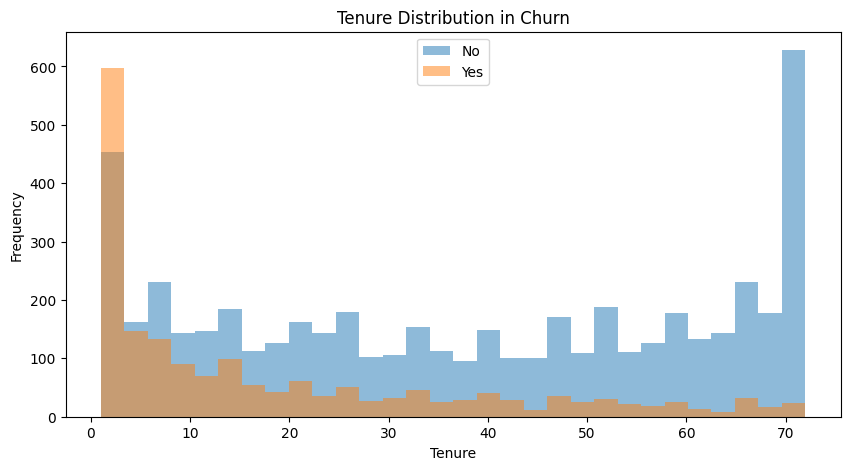

In [29]:
fig, ax=plt.subplots(figsize=(10,5))
for label in df["Churn"].unique():
  subs_1=df[df["Churn"]==label]
  ax.hist(subs_1["tenure"],bins=30, alpha=0.5, label=label)

ax.set(title="Tenure Distribution in Churn")
ax.set(xlabel="Tenure")
ax.set(ylabel="Frequency")
ax.legend()
plt.show()

### **Observation:**
Customers with lower tenure are more likely to churn.  
New customers seem to leave more often than long-term customers.

# Monthly Charges vs Churn
### Monthly charges for churned and non-churned customers

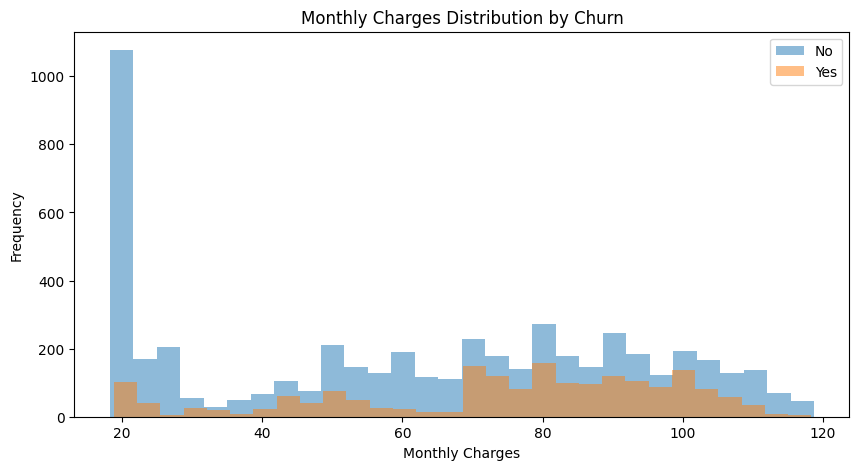

In [24]:
fig, ax= plt.subplots(figsize=(10,5))

for label in df["Churn"].unique():
  seperate=df[df["Churn"]==label]
  ax.hist(seperate["MonthlyCharges"], bins=30, alpha=0.5, label=label)

ax.set(title="Monthly Charges Distribution by Churn")
ax.set(xlabel="Monthly Charges")
ax.set(ylabel="Frequency")
ax.legend()
plt.show()

### **Observation:**
Customers with higher monthly charges appear more likely to churn.  
Price may be an important factor in customer decisions.

#Contract Type vs Churn
This indicates that customers without long-term commitments are more likely to leave.
Contract type will likely be an important feature in the churn prediction model.

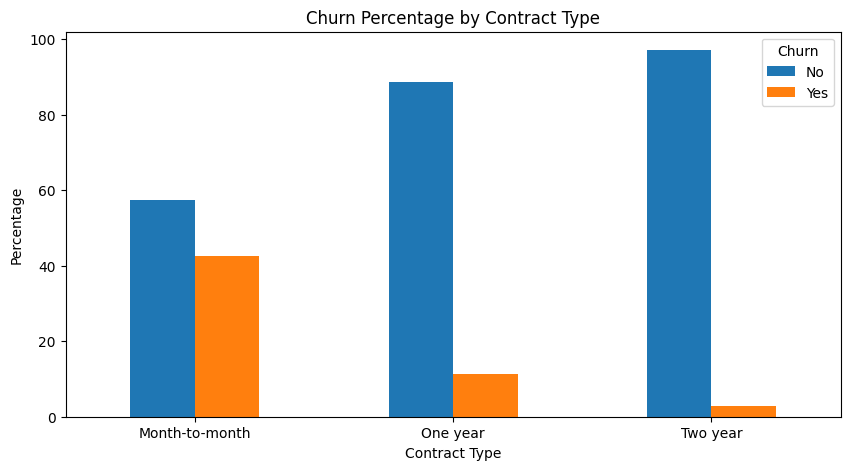

In [41]:
contract_churn=pd.crosstab(df["Contract"],df["Churn"],normalize="index")*100
fig, ax= plt.subplots(figsize=(10,5))
contract_churn.plot(kind="bar", ax=ax)
ax.set(title="Churn Percentage by Contract Type")
ax.set(xlabel="Contract Type")
ax.set(ylabel="Percentage")
plt.xticks(rotation=0)
plt.show()

###**Observation:**

Month-to-month customers have a churn rate of around 43%,
which is significantly higher than one-year (about 11%)
and two-year contracts (around 3%).
This shows that contract length is strongly related to customer retention.

#Correlation Matrix

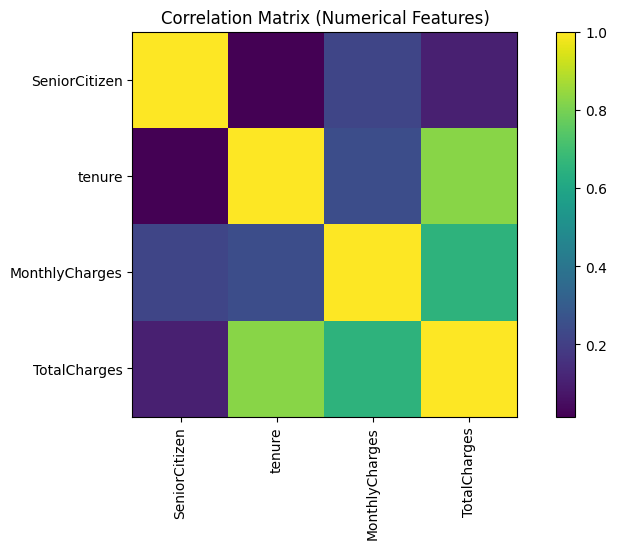

In [42]:
numeric_df=df.select_dtypes(include=["int64","float64"])
corr_matrix=numeric_df.corr()

fig, ax= plt.subplots(figsize=(10,5))
im= ax.imshow(corr_matrix)
fig.colorbar(im)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))

ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set(yticklabels=corr_matrix.columns)
ax.set(title="Correlation Matrix (Numerical Features)")
plt.show()

### **Observation:**
Tenure and TotalCharges are strongly related, which makes sense because longer customers pay more over time.

No extremely strong correlations were found among other numerical features,
so multicollinearity is not a major concern

# Key Findings

1. Customers with short tenure are more likely to churn.
2. Month-to-month contracts have the highest churn rate (around 43%).
3. Customers with higher monthly charges show higher churn tendency.
4. The dataset is moderately imbalanced.

These patterns suggest that tenure, contract type, and monthly charges
will likely be strong predictors in the churn prediction model.